In [1]:
import jax
from jax import random
import jax.numpy as jnp
from jaxkuramoto import odeint, Kuramoto
from jaxkuramoto.distribution import Normal
from jaxkuramoto.solver import runge_kutta
from jaxkuramoto import odeint
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

In [10]:
# 定义 Izhikevich 模型的动态方程
def izhikevich(t, y):
    V, U = y
    dVdt = 0.04 * V**2 + 5 * V + 140 - U + I_ext
    dUdt = a * (b * V - U)
    return [dVdt, dVdt + dUdt]

In [27]:
# Izhikevich 模型参数
a = 0.02
b = 0.2
c = -65
d = 8
I_ext = 10
V_init = -70

In [6]:
# 随机生成自然频率
key = random.PRNGKey(0)
omegas = Normal(0.0, 1.0).sample(key, (n_oscillator,))

In [7]:
# 初始化相位
init_thetas = random.uniform(key, (n_oscillator,)) * 2 * jnp.pi

# 定义 Kuramoto 模型
model = Kuramoto(omegas, K)

In [5]:
# 初始化参数
n_oscillator = 100  # 神经元数量
K = 1.0  # Kuramoto 模型的耦合强度
t_max = 100.0  # 模拟的最大时间
dt = 0.01  # 时间步长

In [8]:
t0, t1, dt = 0.0, 20.0, 0.01
init_thetas = random.uniform(random.PRNGKey(1), (n_oscillator,), maxval=2*jnp.pi)
sol_kuramoto = odeint(model.vector_fn, runge_kutta, t0, t1, dt, init_thetas, model.orderparameter)

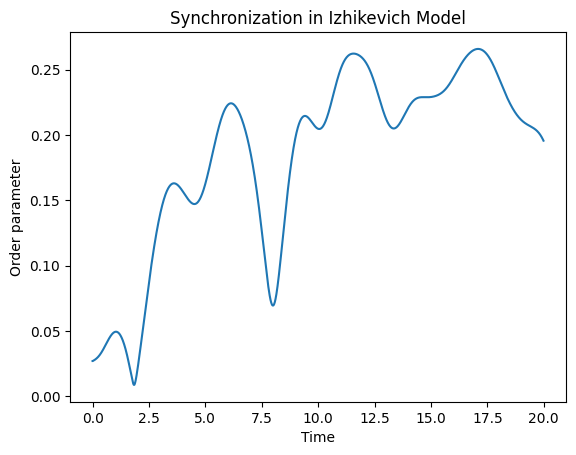

In [9]:
#绘制kuramoto同步性
plt.plot(sol_kuramoto.ts, sol_kuramoto.observables)
plt.xlabel("Time")
plt.ylabel("Order parameter")
plt.title("Synchronization in Izhikevich Model")
plt.show()